In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

In [18]:
raw_data_folder = '../data/raw'
processed_data_folder = '../data/processed'
filename = "deb_reach_birth_noise_1p000_kapnoise_20p0_seed_42.csv"
filename = "sample4D_lhs_N_200000_g_1em3_1e2_k_m4_1_f_0p1_1_ddec_1.csv"
df = pd.read_csv(f'../data/raw/{filename}', )
df

,Row,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
0,1,0.029917,0.460685,0.098951,0.834764,0.363657,40.273707,1,1,1,1,0.063364,none,NaN
1,2,0.031694,0.214933,0.078002,0.537721,0.276909,29.588246,1,1,1,1,0.113557,none,NaN
2,3,0.005513,0.001178,24.571455,0.876544,0.604234,382.813381,1,1,1,1,0.114739,none,NaN
3,4,0.050763,3.752228,0.012638,0.516606,0.358221,25.046061,1,1,1,1,0.320983,none,NaN
4,5,1.044990,6.191878,0.000212,0.238960,0.071532,0.308063,1,0,0,1,0.105362,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,97.646366,0.184548,0.048217,0.263809,0.361889,0.031583,0,1,0,1,2.030902,none,NaN
199996,199997,0.873539,0.000155,5.350341,0.625741,NaN,NaN,0,0,0,0,2.031966,none,NaN
199997,199998,0.002570,0.000321,3.535943,0.381128,0.000000,0.000000,0,0,0,0,6.000000,time_limit_reached,Maximum execution time exceeded
199998,199999,0.609406,0.698152,0.742780,0.995772,0.831474,5.311476,1,1,1,1,2.029901,none,NaN


In [19]:
df['error_type'].value_counts()

error_type
none                  199654
time_limit_reached       346
Name: count, dtype: int64

In [20]:
col_types = {
    'parameter': df.columns[2:9].tolist(),
    'compound_parameter': df.columns[9:16].tolist(),
    'birth_simulation': df.columns[16:21].tolist(),
    'info': df.columns[0:2].tolist(),
    'log': df.columns[21:].tolist()
}
print(col_types)

{'parameter': ['k', 'v_Hb', 'f', 'lb', 'tb', 'lb<f', 'k*vHb<c'], 'compound_parameter': ['reached_birth', 'success', 'execution_time', 'error_type', 'error_message'], 'birth_simulation': [], 'info': ['Row', 'g'], 'log': []}


In [21]:
df['reached_birth'] = df['reached_birth'].astype(bool)
df['lb<f'] = df['lb<f'].astype(bool)
df['k*vHb<c'] = df['k*vHb<c'].astype(bool)

In [22]:
df = df[df['execution_time'] > 0].copy()
df[df[col_types['parameter'] + col_types['compound_parameter']].isna().any(axis=1)]

,Row,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
0,1,0.029917,0.460685,0.098951,0.834764,0.363657,40.273707,True,True,True,1,0.063364,none,NaN
1,2,0.031694,0.214933,0.078002,0.537721,0.276909,29.588246,True,True,True,1,0.113557,none,NaN
2,3,0.005513,0.001178,24.571455,0.876544,0.604234,382.813381,True,True,True,1,0.114739,none,NaN
3,4,0.050763,3.752228,0.012638,0.516606,0.358221,25.046061,True,True,True,1,0.320983,none,NaN
4,5,1.044990,6.191878,0.000212,0.238960,0.071532,0.308063,True,False,False,1,0.105362,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199994,199995,0.026238,3.508315,0.441373,0.638964,NaN,NaN,False,False,False,0,0.034871,none,NaN
199995,199996,97.646366,0.184548,0.048217,0.263809,0.361889,0.031583,False,True,False,1,2.030902,none,NaN
199996,199997,0.873539,0.000155,5.350341,0.625741,NaN,NaN,False,False,False,0,2.031966,none,NaN
199998,199999,0.609406,0.698152,0.742780,0.995772,0.831474,5.311476,True,True,True,1,2.029901,none,NaN


In [23]:
# Filter out rows with infinite values
df = df[df['execution_time'] > 0].copy()
# Filter out too small values for k*vHb
#df = df[df['k'] * df['v_Hb'] > 1e-16].copy()
#df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=col_types['parameter'] + col_types['compound_parameter'])
df

,Row,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
0,1,0.029917,0.460685,0.098951,0.834764,0.363657,40.273707,True,True,True,1,0.063364,none,NaN
1,2,0.031694,0.214933,0.078002,0.537721,0.276909,29.588246,True,True,True,1,0.113557,none,NaN
2,3,0.005513,0.001178,24.571455,0.876544,0.604234,382.813381,True,True,True,1,0.114739,none,NaN
3,4,0.050763,3.752228,0.012638,0.516606,0.358221,25.046061,True,True,True,1,0.320983,none,NaN
4,5,1.044990,6.191878,0.000212,0.238960,0.071532,0.308063,True,False,False,1,0.105362,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,97.646366,0.184548,0.048217,0.263809,0.361889,0.031583,False,True,False,1,2.030902,none,NaN
199996,199997,0.873539,0.000155,5.350341,0.625741,NaN,NaN,False,False,False,0,2.031966,none,NaN
199997,199998,0.002570,0.000321,3.535943,0.381128,0.000000,0.000000,False,False,False,0,6.000000,time_limit_reached,Maximum execution time exceeded
199998,199999,0.609406,0.698152,0.742780,0.995772,0.831474,5.311476,True,True,True,1,2.029901,none,NaN


In [24]:
df[['g', 'k', 'v_Hb', 'f']].describe()

,g,k,v_Hb,f
count,200000.000000,200000.000000,2.000000e+05,200000.000000
mean,8.685805,0.868580,1.928039e+02,0.550000
std,18.943424,1.894342,1.599399e+03,0.259808
min,0.001000,0.000100,1.499035e-07,0.100001
25%,0.017783,0.001778,3.313464e-02,0.325002
50%,0.316231,0.031622,3.431739e-01,0.550001
75%,5.623470,0.562324,5.386563e+00,0.774997
max,99.998241,9.999598,8.447736e+04,0.999996


<Axes: xlabel='v_Hb', ylabel='Count'>

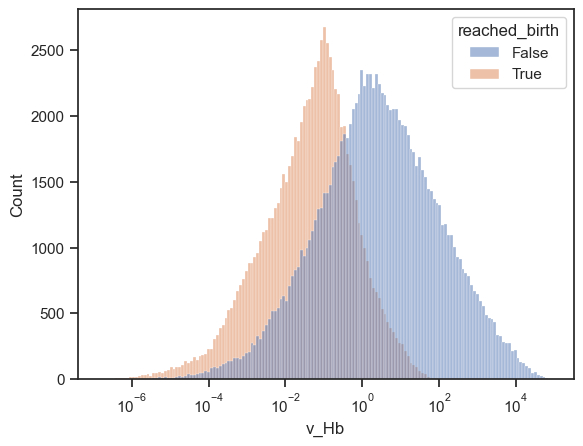

In [25]:
sns.histplot(data=df, x='v_Hb', hue='reached_birth', common_norm=False, log_scale=True )

<Axes: xlabel='k', ylabel='Count'>

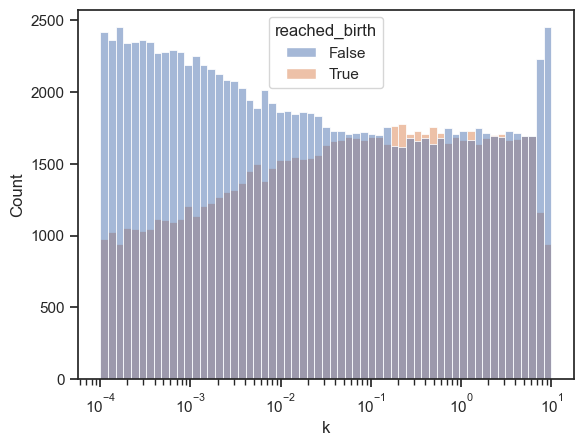

In [26]:
sns.histplot(data=df, x='k', hue='reached_birth', common_norm=False, log_scale=True )


<Axes: xlabel='g', ylabel='Count'>

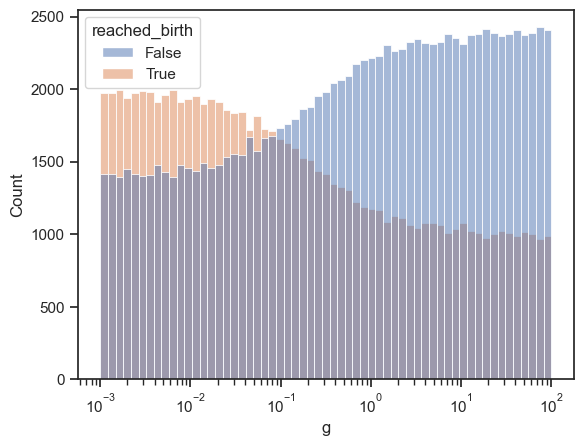

In [27]:
sns.histplot(data=df, x='g', hue='reached_birth', common_norm=False, log_scale=True )

<Axes: xlabel='None', ylabel='Count'>

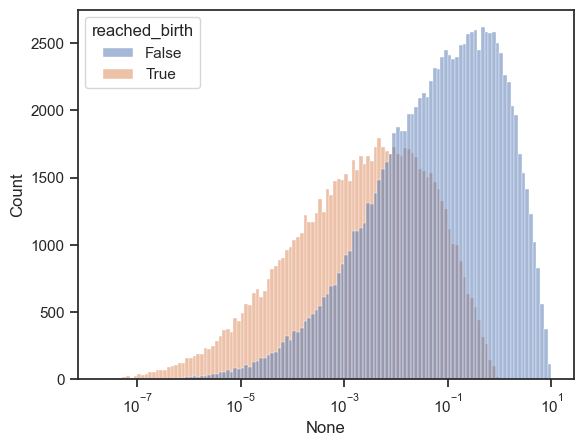

In [28]:
sns.histplot(x=df['k']*df['v_Hb'], hue=df['reached_birth'], common_norm=False, log_scale=True )


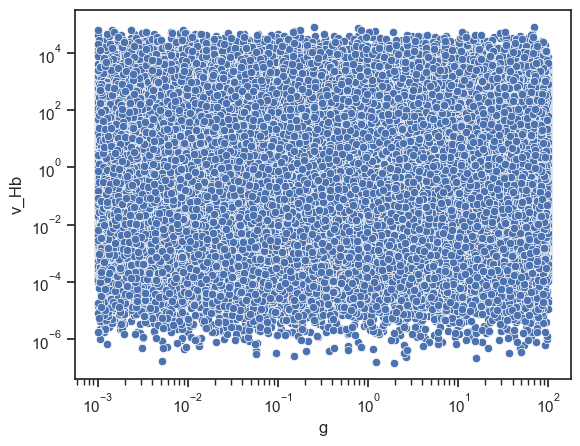

In [29]:
ax = sns.scatterplot(data=df, x='g', y='v_Hb')
ax.set_xscale('log')
ax.set_yscale('log')

In [30]:
df['reached_birth'].mean()

np.float64(0.43004)

In [31]:
df[['lb<f', 'k*vHb<c']].value_counts()

lb<f   k*vHb<c
True   True       86008
False  False      75991
       True       28422
True   False       9579
Name: count, dtype: int64

<Axes: xlabel='execution_time', ylabel='Count'>

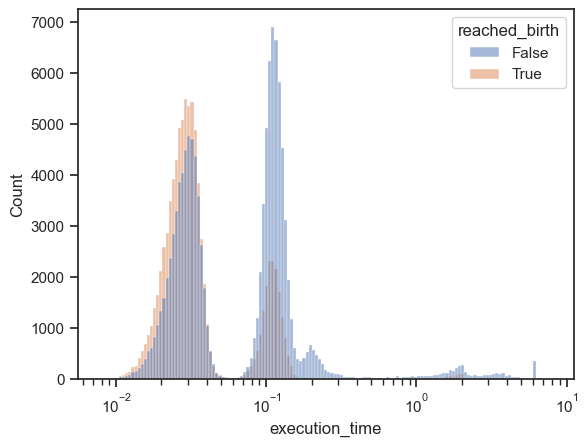

In [33]:
sns.histplot(data=df, x='execution_time', hue='reached_birth', common_norm=False, log_scale=True )

## Split data and save

In [35]:
df.to_csv(f'{processed_data_folder}/deb_reach_birth.csv', index=False)
from sklearn.model_selection import train_test_split
train__frac = 0.8
test_frac = 0.1
val_frac = 0.1
# First split into train and temp (val + test)
train_df, temp_df = train_test_split(df, test_size=(1 - train__frac), random_state=42, stratify=df['reached_birth'])
# Then split temp into val and test
val_df, test_df = train_test_split(temp_df, test_size=(test_frac / (test_frac + val_frac)), random_state=42, stratify=temp_df['reached_birth'])
# Check sizes
print(f'Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}')
# Save to csv
train_df.to_csv(f'{processed_data_folder}/train.csv', index=False)
val_df.to_csv(f'{processed_data_folder}/val.csv', index=False)
test_df.to_csv(f'{processed_data_folder}/test.csv', index=False)

Train size: 160000, Val size: 20000, Test size: 20000
